# Detecção de Pragas Agrícolas | Projeto Integrador & Imagem Digital
Este notebook implementa um pipeline completo para treinar um modelo de detecção de objetos focado em pragas agrícolas. Utilizaremos o poder das **duas GPUs T4** disponíveis no Kaggle para acelerar o treinamento, ajustando hiperparâmetros específicos para detecção de pequenos insetos em imagens digitais.

In [20]:
# 1. Instalação e Setup
!pip install -U ultralytics wandb kagglehub -q

import os
import yaml
import random
import shutil
import matplotlib.pyplot as plt
from PIL import Image
import kagglehub
from ultralytics import YOLO
import ultralytics

ultralytics.checks()

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6673.4/8062.4 GB disk)


In [65]:
output_dir = "relatorio_dataset"
os.makedirs(output_dir, exist_ok=True)

In [21]:
# 2. Download do Dataset e Correção de Rotas do YAML
dataset_path = kagglehub.dataset_download('rupankarmajumdar/crop-pests-dataset')
print(f"Dataset baixado com sucesso em: {dataset_path}")

yaml_file = os.path.join(dataset_path, 'data.yaml')
with open(yaml_file, 'r') as f:
    data_config = yaml.safe_load(f)

# Corrigindo caminhos relativos que quebram no Kaggle
data_config['train'] = os.path.join(dataset_path, 'train/images')
data_config['val'] = os.path.join(dataset_path, 'valid/images')
data_config['test'] = os.path.join(dataset_path, 'test/images')

working_yaml = '/kaggle/working/agropest_fixed.yaml'
with open(working_yaml, 'w') as f:
    yaml.dump(data_config, f)

print(f"Novo arquivo de configuração gerado: {working_yaml}")

Dataset baixado com sucesso em: /kaggle/input/datasets/rupankarmajumdar/crop-pests-dataset
Novo arquivo de configuração gerado: /kaggle/working/agropest_fixed.yaml


In [22]:
# 3. Treinamento Multi-GPU (Dual T4)
train_args = {
    'data': working_yaml,
    'epochs': 50,                 
    'patience': 25,                
    'imgsz': 800,                 # Resolução alta para insetos pequenos
    'batch': 16,                   # Reduzido para 16 para a GPU não estourar a memória
    'device': '0,1',               # ATIVA AS DUAS GPUs
    'workers': 8,                  
    'cos_lr': True,                
    'close_mosaic': 10,            
    'project': 'Projeto_Integrador', 
    'name': 'yolo_treinamento',
    'exist_ok': True
    
    # OBS: Otimizador e LR removidos para o YOLO fazer a auto-calibração mágica!
}

model = YOLO('yolov8n.pt') # Modelo Medium ativado!
results = model.train(**train_args)
print("Treinamento concluído! Pesos salvos no diretório do projeto.")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/agropest_fixed.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_treinamento, nbs=64, nms=

In [23]:
# 4. Avaliação no Conjunto de Teste
print("Avaliando o modelo no conjunto de teste estrito...")
metrics = model.val(data=working_yaml, split='test')

print(f"mAP@50 (Mean Average Precision): {metrics.box.map50:.4f}")
print(f"mAP@50-95 (Métrica rigorosa): {metrics.box.map:.4f}")

Avaliando o modelo no conjunto de teste estrito...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 10.7±8.2 MB/s, size: 33.5 KB)
val: Scanning /kaggle/input/datasets/rupankarmajumdar/crop-pests-dataset/test/labels... 546 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 546/546 119.9it/s 4.6s<0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/rupankarmajumdar/crop-pests-dataset/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 4.7it/s 7.4s0.2s
                   all        546        689      0.832      0.693      0.764      0.437
                  Ants         54         87      0.896      0.594      0.767      0.305
                  Bees         40         44      0.862      0.841       0.91      0.448
       

✅ Sucesso! Pesos encontrados em: /kaggle/working/runs/detect/Projeto_Integrador/yolo_treinamento/weights/best.pt
🔍 Analisando as imagens...

image 1/13 /kaggle/working/sample_inference/Weevil-237-_jpg.rf.9dfe41f1c17cfbbbb48c432ddd1c91b7.jpg: 800x800 1 Weevils, 9.7ms
image 2/13 /kaggle/working/sample_inference/Weevil-418-_jpg.rf.8341fc9e7ce407d295b190a4445925c4.jpg: 800x800 1 Weevils, 9.7ms
image 3/13 /kaggle/working/sample_inference/bees-14-_jpg.rf.d829d810bb31d9db7578a9f44a07cff4.jpg: 800x800 1 Bees, 9.7ms
image 4/13 /kaggle/working/sample_inference/bees-176-_jpg.rf.361df4f8a059008ef90977bff46b3de5.jpg: 800x800 1 Bees, 9.7ms
image 5/13 /kaggle/working/sample_inference/beetle-170-_jpg.rf.a74a51f4841007ed9a7af31f330ab459.jpg: 800x800 (no detections), 9.7ms
image 6/13 /kaggle/working/sample_inference/catterpillar-218-_jpg.rf.83003926c0ade000676224fc35351fec.jpg: 800x800 (no detections), 9.7ms
image 7/13 /kaggle/working/sample_inference/catterpillar-23-_jpg.rf.61f1c8431272dbb579fc0c9c44c9

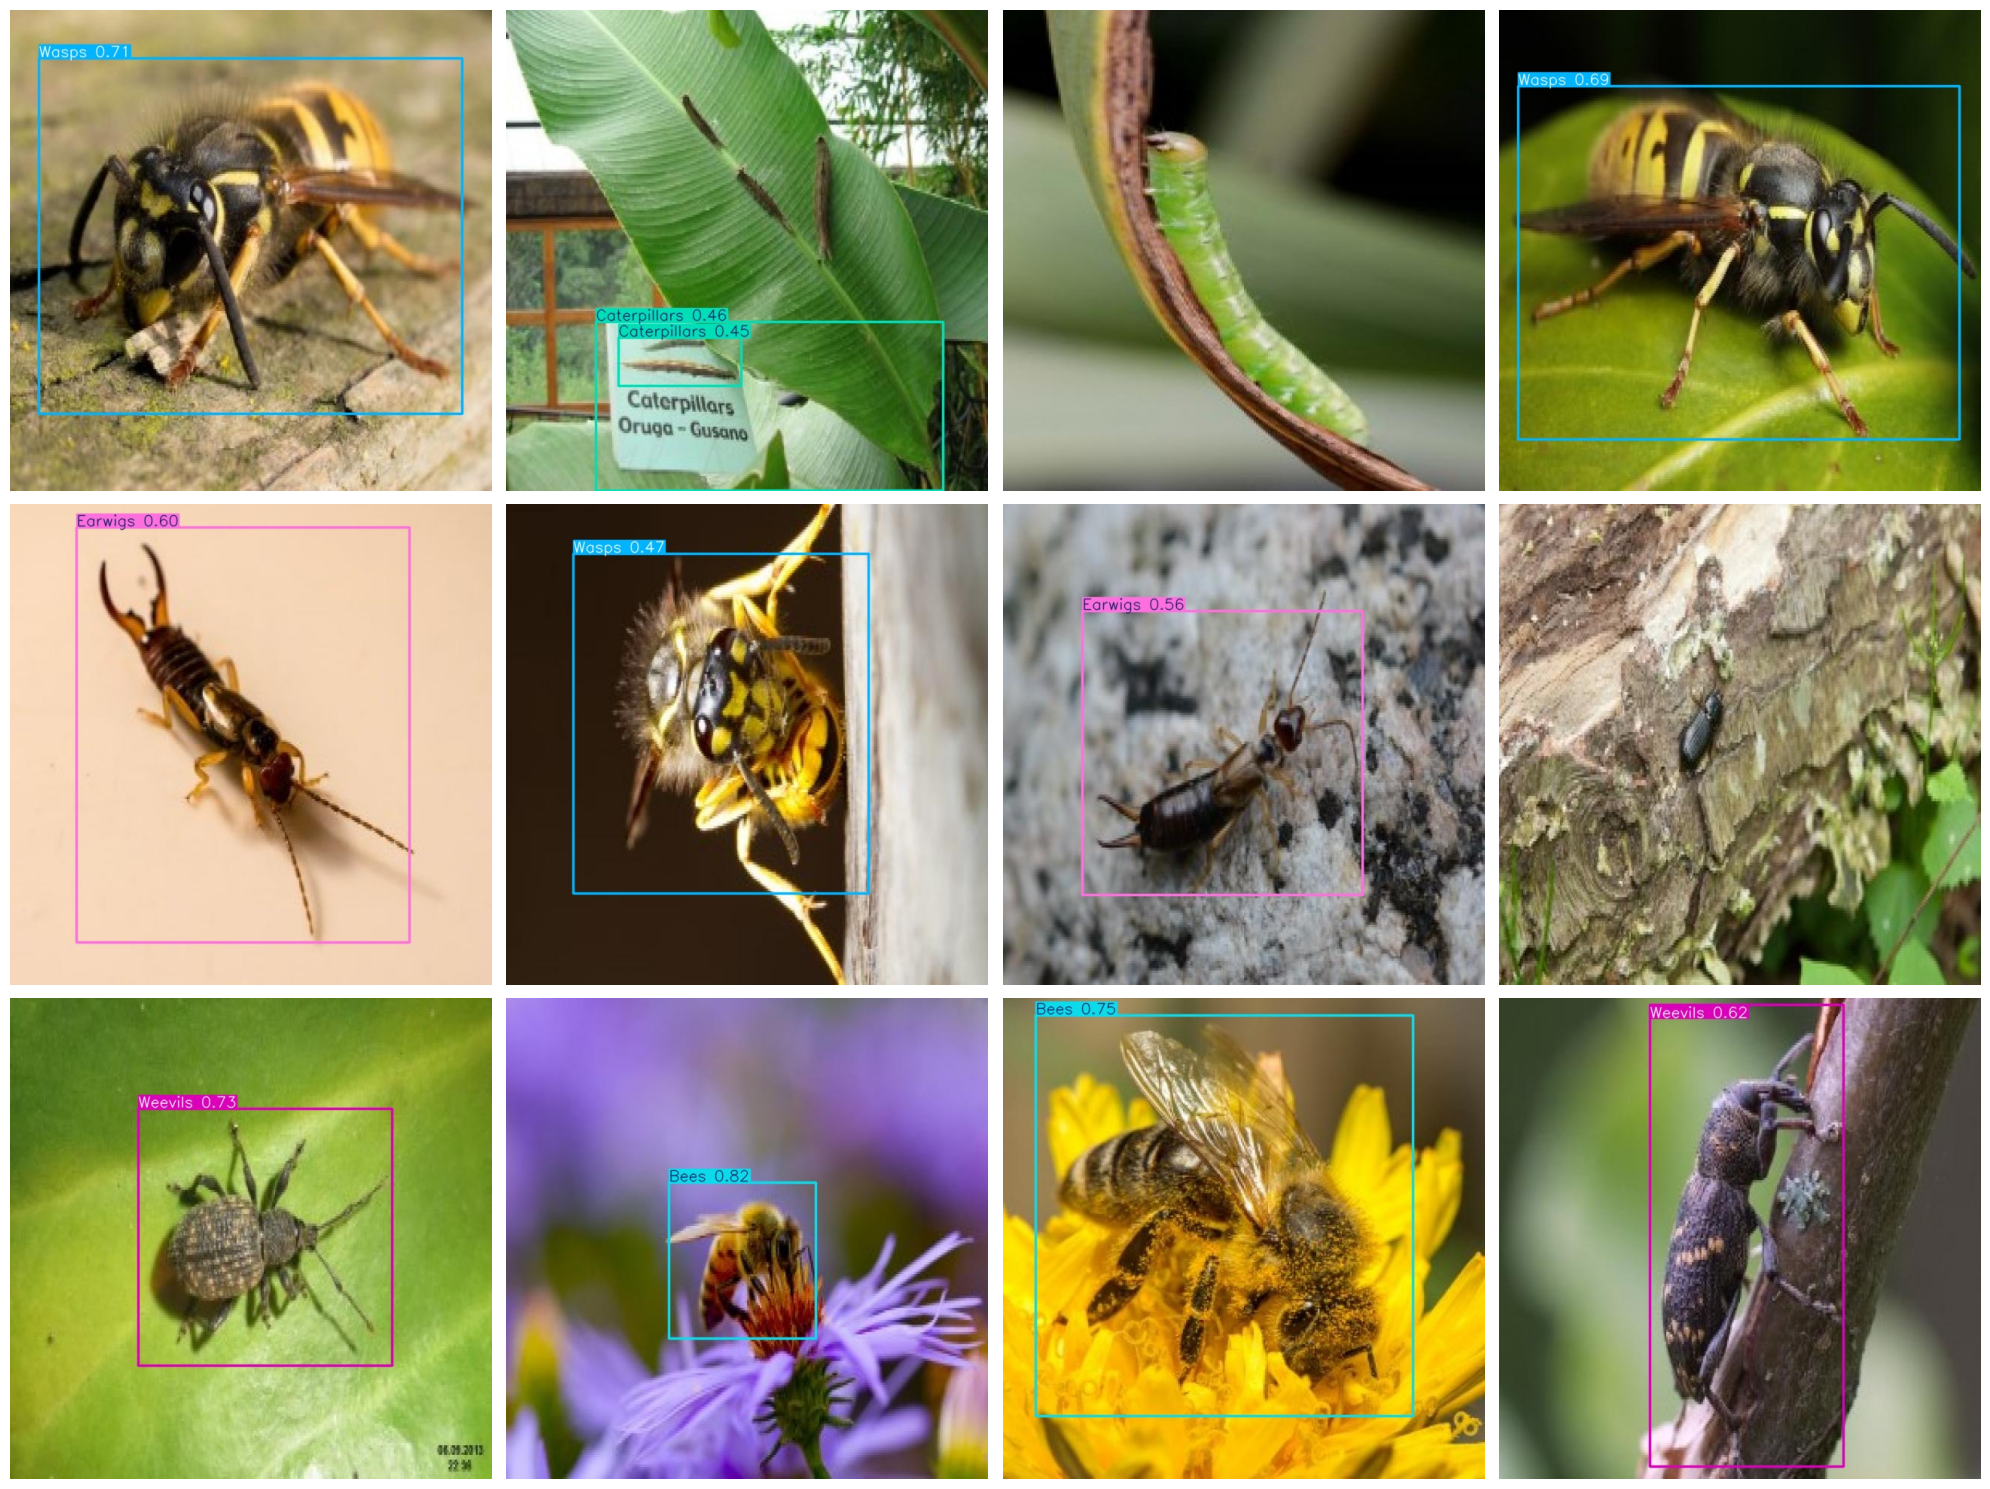

In [24]:
# 5. Inferência e Visualização de Resultados
import glob
import os
import random
import shutil
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
import yaml

# Busca o arquivo de pesos do modelo treinado
arquivos_pesos = glob.glob('/kaggle/working/**/weights/best.pt', recursive=True)

if not arquivos_pesos:
    print("❌ ERRO: O arquivo best.pt não foi encontrado.")
else:
    best_weights_path = max(arquivos_pesos, key=os.path.getctime)
    print(f"✅ Sucesso! Pesos encontrados em: {best_weights_path}")
    
    best_model = YOLO(best_weights_path)

    # Lendo o YAML para pegar o caminho exato e seguro das imagens de teste
    yaml_path = '/kaggle/working/agropest_fixed.yaml'
    with open(yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)
    
    test_dir = data_config['test']

    sample_dir = '/kaggle/working/sample_inference'
    os.makedirs(sample_dir, exist_ok=True)

    all_test_imgs = [f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    sample_imgs = random.sample(all_test_imgs, min(12, len(all_test_imgs)))

    for img in sample_imgs:
        shutil.copy(os.path.join(test_dir, img), os.path.join(sample_dir, img))

    # Realizando a predição nas imagens separadas
    print("🔍 Analisando as imagens...")
    predict_results = best_model.predict(
        source=sample_dir, 
        conf=0.40, 
        save=True, 
        project='Projeto_Integrador_Rafa', 
        name='predicoes',
        exist_ok=True 
    )

    # Buscando onde as predições com as caixas coloridas foram salvas
    pastas_pred = glob.glob('/kaggle/working/**/Projeto_Integrador_Rafa/predicoes*', recursive=True)
    pred_dir = max(pastas_pred, key=os.path.getctime)
    pred_files = [f for f in os.listdir(pred_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

    # Plotando a grade de resultados
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    for ax, file in zip(axes.flatten(), pred_files):
        img_path = os.path.join(pred_dir, file)
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [25]:
# 6. Exportação e Empacotamento
# Exporta o modelo para ONNX (formato universal para integração)
best_model.export(format='onnx')

!zip -r Resultados_Completos_PI.zip /kaggle/working/Projeto_Integrador_Rafa
print("Arquivo ZIP gerado! Baixe-o no painel 'Output' à direita.")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/kaggle/working/runs/detect/Projeto_Integrador/yolo_treinamento/weights/best.pt' with input shape (1, 3, 800, 800) BCHW and output shape(s) (1, 16, 13125) (6.0 MB)

ONNX: starting export with onnx 1.20.1 opset 22...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.87...
ONNX: export success ✅ 1.1s, saved as '/kaggle/working/runs/detect/Projeto_Integrador/yolo_treinamento/weights/best.onnx' (11.8 MB)

Export complete (1.4s)
Results saved to /kaggle/working/runs/detect/Projeto_Integrador/yolo_treinamento/weights
Predict:         yolo predict task=detect model=/kaggle/working/runs/detect/Projeto_Integrador/yolo_treinamento/weights/best.onnx imgsz=800 
Validate:        yolo val task=detect model=/kaggle/working/runs/detect/Projeto_Integrador/yolo_treinamento/weights/best.onnx imgsz=800 data=/kaggle/working/agropest_fixed.yaml  
Visualize:       https://netron.app
	zip warning: name not matched: /kaggle/working/Projeto_Integrador_Rafa

zip error: Nothing to do! (try: zip -r Resultados_Completos_PI.zip . -i /kaggle/working/Projeto_Integrador_Rafa)
Arquivo ZIP gerado! Baixe-o no painel 'Output' à direita.


In [26]:
!zip -r Resultados_Completos_PI.zip /kaggle/working

updating: kaggle/working/ (stored 0%)
updating: kaggle/working/.virtual_documents/ (stored 0%)
updating: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 58%)
updating: kaggle/working/yolo11m.pt (deflated 8%)
updating: kaggle/working/runs/ (stored 0%)
updating: kaggle/working/runs/detect/ (stored 0%)
updating: kaggle/working/runs/detect/Projeto_Integrador_Rafa/ (stored 0%)
updating: kaggle/working/runs/detect/Projeto_Integrador_Rafa/yolo_treinamento/ (stored 0%)
updating: kaggle/working/runs/detect/Projeto_Integrador_Rafa/yolo_treinamento/args.yaml (deflated 52%)
updating: kaggle/working/runs/detect/Projeto_Integrador_Rafa/yolo_treinamento/weights/ (stored 0%)
updating: kaggle/working/runs/detect/Projeto_Integrador_Rafa/predicoes/ (stored 0%)
updating: kaggle/working/runs/detect/Projeto_Integrador_Rafa/predicoes/wasp-710-_jpg.rf.f7de287c9c13168c025419e7e10c5f4a.jpg (deflated 5%)
updating: kaggle/working/runs/detect/Projeto_Integrador_Rafa/predicoes/catterpillar-23-

In [27]:
from IPython.display import FileLink, display

# Cria um link de download direto para o arquivo ZIP gerado
display(FileLink('Resultados_Completos_PI.zip'))

/kaggle/working/Resultados_Completos_PI.zip

In [29]:
import os

os.listdir("runs/detect")

['Projeto_Integrador_Rafa', 'val2', 'Projeto_Integrador', 'val']

In [34]:
import os
os.getcwd()

'/kaggle/working'

In [35]:
os.listdir("/kaggle/working")

['yolov8n.pt',
 '.virtual_documents',
 'yolo11m.pt',
 'runs',
 'agropest_fixed.yaml',
 'sample_inference',
 'yolo26n.pt',
 'Resultados_Completos_PI.zip']

In [36]:
import os

os.listdir("runs")

['detect']

In [37]:
import os

os.listdir("runs/detect")

['Projeto_Integrador_Rafa', 'val2', 'Projeto_Integrador', 'val']

In [39]:
import os

for root, dirs, files in os.walk("runs"):
    for file in files:
        if file == "results.csv":
            print(os.path.join(root, file))

runs/detect/Projeto_Integrador/yolo_treinamento/results.csv


In [41]:
import os

for root, dirs, files in os.walk("runs/detect"):
    for file in files:
        if file == "results.csv":
            print(os.path.join(root, file))

runs/detect/Projeto_Integrador/yolo_treinamento/results.csv


In [42]:
import zipfile

zip_path = "Resultados_Completos_PI.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for file in zip_ref.namelist():
        if "results.csv" in file:
            print(file)

kaggle/working/runs/detect/Projeto_Integrador_Rafa/yolo_treinamento/results.csv
kaggle/working/runs/detect/Projeto_Integrador/yolo_treinamento/results.csv


In [45]:
import os

paths = []

for root, dirs, files in os.walk("."):
    for file in files:
        if file == "results.csv":
            full_path = os.path.join(root, file)
            paths.append(full_path)
            print(full_path)

print("\nTotal encontrados:", len(paths))

./runs/detect/Projeto_Integrador/yolo_treinamento/results.csv

Total encontrados: 1


In [47]:
import zipfile

with zipfile.ZipFile("Resultados_Completos_PI.zip", 'r') as zip_ref:
    zip_ref.extractall("resultados_extraidos")

In [48]:
import os

for root, dirs, files in os.walk("resultados_extraidos"):
    for file in files:
        if file == "results.csv":
            print(os.path.join(root, file))

resultados_extraidos/kaggle/working/runs/detect/Projeto_Integrador_Rafa/yolo_treinamento/results.csv
resultados_extraidos/kaggle/working/runs/detect/Projeto_Integrador/yolo_treinamento/results.csv


In [49]:
import pandas as pd

# caminhos corretos
yolo11_path = "resultados_extraidos/kaggle/working/runs/detect/Projeto_Integrador_Rafa/yolo_treinamento/results.csv"
yolov8_path = "resultados_extraidos/kaggle/working/runs/detect/Projeto_Integrador/yolo_treinamento/results.csv"

# carregar arquivos
yolo11 = pd.read_csv(yolo11_path)
yolov8 = pd.read_csv(yolov8_path)

# pegar última época (resultado final)
yolo11_last = yolo11.iloc[-1]
yolov8_last = yolov8.iloc[-1]

# criar tabela comparativa
comparacao = pd.DataFrame({
    "Modelo": ["YOLOv8n", "YOLO11m"],

    "mAP50": [
        yolov8_last["metrics/mAP50(B)"],
        yolo11_last["metrics/mAP50(B)"]
    ],

    "mAP50-95": [
        yolov8_last["metrics/mAP50-95(B)"],
        yolo11_last["metrics/mAP50-95(B)"]
    ],

    "Precision": [
        yolov8_last["metrics/precision(B)"],
        yolo11_last["metrics/precision(B)"]
    ],

    "Recall": [
        yolov8_last["metrics/recall(B)"],
        yolo11_last["metrics/recall(B)"]
    ]
})

print("\n===== COMPARAÇÃO DOS MODELOS =====\n")
print(comparacao)

# salvar tabela
comparacao.to_csv("comparacao_yolov8n_vs_yolo11m.csv", index=False)

print("\nArquivo salvo: comparacao_yolov8n_vs_yolo11m.csv")


===== COMPARAÇÃO DOS MODELOS =====

    Modelo    mAP50  mAP50-95  Precision   Recall
0  YOLOv8n  0.75211   0.43062    0.79315  0.70960
1  YOLO11m  0.76948   0.46211    0.80256  0.72187

Arquivo salvo: comparacao_yolov8n_vs_yolo11m.csv


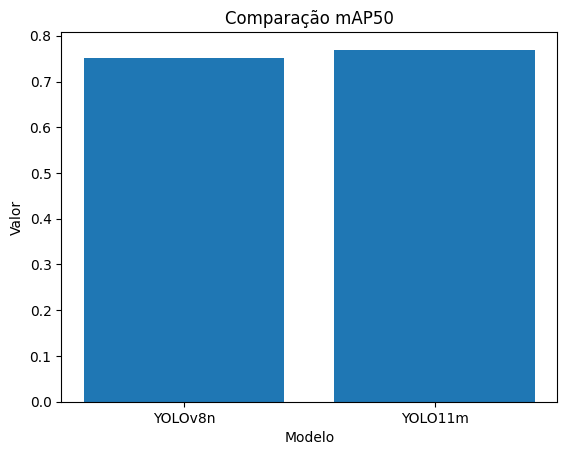

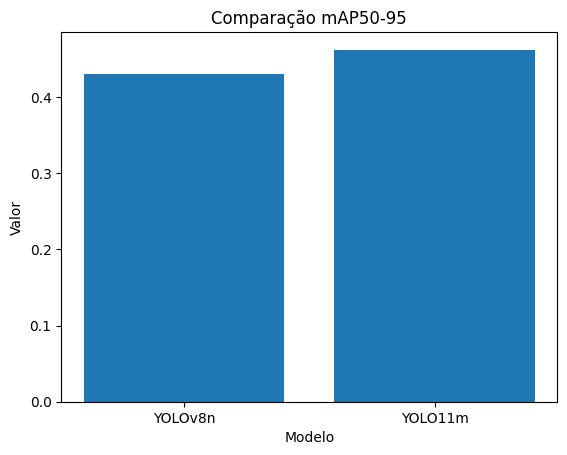

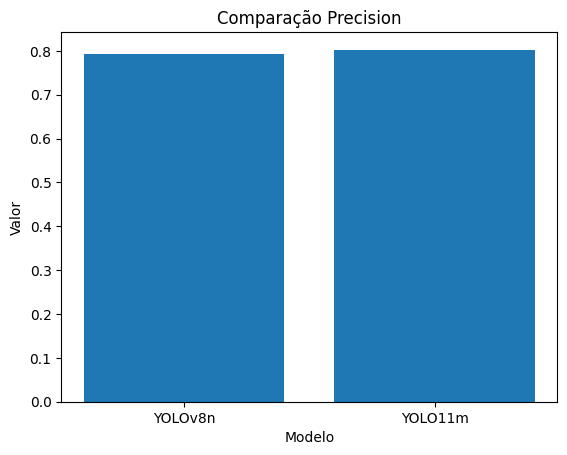

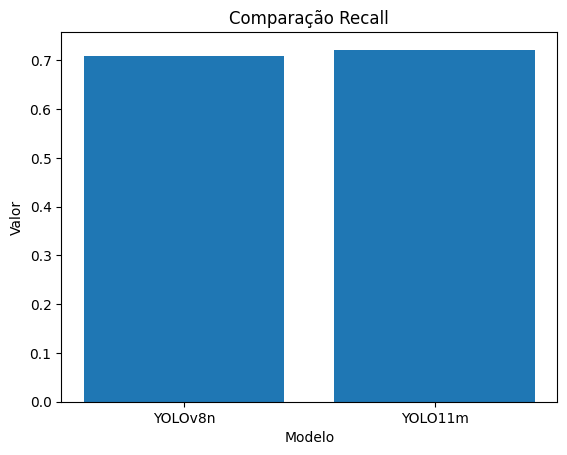

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# caminhos dos arquivos
yolo11_path = "resultados_extraidos/kaggle/working/runs/detect/Projeto_Integrador_Rafa/yolo_treinamento/results.csv"
yolov8_path = "resultados_extraidos/kaggle/working/runs/detect/Projeto_Integrador/yolo_treinamento/results.csv"

# carregar dados
yolo11 = pd.read_csv(yolo11_path)
yolov8 = pd.read_csv(yolov8_path)

# pegar última época
yolo11_last = yolo11.iloc[-1]
yolov8_last = yolov8.iloc[-1]

# métricas
modelos = ["YOLOv8n", "YOLO11m"]

map50 = [
    yolov8_last["metrics/mAP50(B)"],
    yolo11_last["metrics/mAP50(B)"]
]

map5095 = [
    yolov8_last["metrics/mAP50-95(B)"],
    yolo11_last["metrics/mAP50-95(B)"]
]

precision = [
    yolov8_last["metrics/precision(B)"],
    yolo11_last["metrics/precision(B)"]
]

recall = [
    yolov8_last["metrics/recall(B)"],
    yolo11_last["metrics/recall(B)"]
]

# gráfico mAP50
plt.figure()
plt.bar(modelos, map50)
plt.title("Comparação mAP50")
plt.ylabel("Valor")
plt.xlabel("Modelo")
plt.show()

# gráfico mAP50-95
plt.figure()
plt.bar(modelos, map5095)
plt.title("Comparação mAP50-95")
plt.ylabel("Valor")
plt.xlabel("Modelo")
plt.show()

# gráfico Precision
plt.figure()
plt.bar(modelos, precision)
plt.title("Comparação Precision")
plt.ylabel("Valor")
plt.xlabel("Modelo")
plt.show()

# gráfico Recall
plt.figure()
plt.bar(modelos, recall)
plt.title("Comparação Recall")
plt.ylabel("Valor")
plt.xlabel("Modelo")
plt.show()

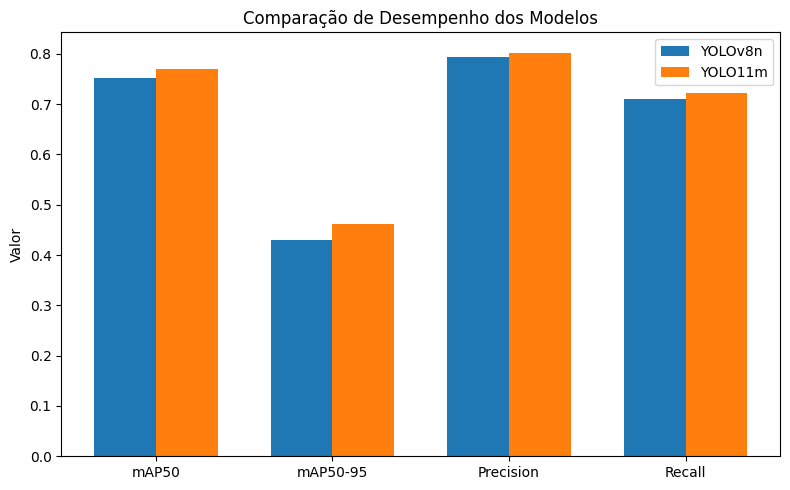

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# caminhos dos arquivos
yolo11_path = "resultados_extraidos/kaggle/working/runs/detect/Projeto_Integrador_Rafa/yolo_treinamento/results.csv"
yolov8_path = "resultados_extraidos/kaggle/working/runs/detect/Projeto_Integrador/yolo_treinamento/results.csv"

# carregar dados
yolo11 = pd.read_csv(yolo11_path)
yolov8 = pd.read_csv(yolov8_path)

# última época
yolo11_last = yolo11.iloc[-1]
yolov8_last = yolov8.iloc[-1]

# métricas
metricas = ["mAP50", "mAP50-95", "Precision", "Recall"]

yolov8_values = [
    yolov8_last["metrics/mAP50(B)"],
    yolov8_last["metrics/mAP50-95(B)"],
    yolov8_last["metrics/precision(B)"],
    yolov8_last["metrics/recall(B)"]
]

yolo11_values = [
    yolo11_last["metrics/mAP50(B)"],
    yolo11_last["metrics/mAP50-95(B)"],
    yolo11_last["metrics/precision(B)"],
    yolo11_last["metrics/recall(B)"]
]

# posição das barras
x = np.arange(len(metricas))
width = 0.35

# criar gráfico
plt.figure(figsize=(8,5))

plt.bar(x - width/2, yolov8_values, width, label="YOLOv8n")
plt.bar(x + width/2, yolo11_values, width, label="YOLO11m")

plt.xticks(x, metricas)
plt.ylabel("Valor")
plt.title("Comparação de Desempenho dos Modelos")
plt.legend()

plt.tight_layout()
plt.show()

In [52]:
import os

train_path = os.path.join(dataset_path, 'train/images')

# contar imagens
train_images = [f for f in os.listdir(train_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

print("Quantidade de imagens de treino:", len(train_images))

Quantidade de imagens de treino: 11502


In [53]:
def contar_imagens(path):
    return len([f for f in os.listdir(path) if f.endswith(('.jpg','.jpeg','.png'))])

train_path = os.path.join(dataset_path, 'train/images')
val_path = os.path.join(dataset_path, 'valid/images')
test_path = os.path.join(dataset_path, 'test/images')

print("Imagens de TREINO:", contar_imagens(train_path))
print("Imagens de VALIDAÇÃO:", contar_imagens(val_path))
print("Imagens de TESTE:", contar_imagens(test_path))

Imagens de TREINO: 11502
Imagens de VALIDAÇÃO: 1095
Imagens de TESTE: 546


In [54]:
import os
import pandas as pd
from collections import Counter

train_img = os.path.join(dataset_path, 'train/images')
train_lbl = os.path.join(dataset_path, 'train/labels')

val_img = os.path.join(dataset_path, 'valid/images')
val_lbl = os.path.join(dataset_path, 'valid/labels')

test_img = os.path.join(dataset_path, 'test/images')
test_lbl = os.path.join(dataset_path, 'test/labels')


def contar_imagens(path):
    return len([f for f in os.listdir(path) if f.endswith(('.jpg','.jpeg','.png'))])


def contar_labels(path):
    return len([f for f in os.listdir(path) if f.endswith('.txt')])


def contar_classes(labels_path):
    classes = []

    for file in os.listdir(labels_path):
        if file.endswith(".txt"):
            with open(os.path.join(labels_path, file)) as f:
                for line in f:
                    classes.append(int(line.split()[0]))

    return Counter(classes)


# contagem imagens
train_images = contar_imagens(train_img)
val_images = contar_imagens(val_img)
test_images = contar_imagens(test_img)

# contagem labels
train_labels = contar_labels(train_lbl)
val_labels = contar_labels(val_lbl)
test_labels = contar_labels(test_lbl)

# contagem classes
class_counts = contar_classes(train_lbl)

# tabela resumo
dataset_info = pd.DataFrame({
    "Conjunto": ["Treino", "Validação", "Teste"],
    "Imagens": [train_images, val_images, test_images],
    "Labels": [train_labels, val_labels, test_labels]
})

print("\n===== RESUMO DO DATASET =====\n")
print(dataset_info)

print("\n===== OBJETOS POR CLASSE =====\n")
for classe, quantidade in class_counts.items():
    print(f"Classe {classe}: {quantidade} objetos")

total_objetos = sum(class_counts.values())

print("\n===== ESTATÍSTICAS =====")
print("Total de objetos:", total_objetos)
print("Total de classes:", len(class_counts))
print("Média de objetos por imagem:", round(total_objetos/train_images,2))


===== RESUMO DO DATASET =====

    Conjunto  Imagens  Labels
0     Treino    11502   11502
1  Validação     1095    1095
2      Teste      546     546

===== OBJETOS POR CLASSE =====

Classe 7: 1062 objetos
Classe 11: 975 objetos
Classe 2: 1058 objetos
Classe 4: 1083 objetos
Classe 0: 2231 objetos
Classe 1: 1596 objetos
Classe 6: 1071 objetos
Classe 10: 1167 objetos
Classe 9: 1199 objetos
Classe 8: 918 objetos
Classe 5: 1182 objetos
Classe 3: 1740 objetos

===== ESTATÍSTICAS =====
Total de objetos: 15282
Total de classes: 12
Média de objetos por imagem: 1.33


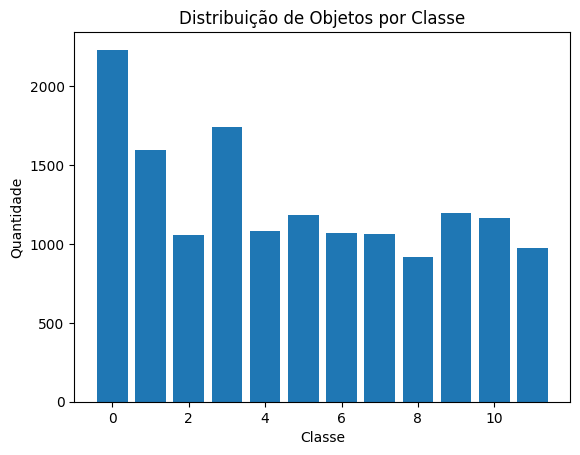

In [55]:
import matplotlib.pyplot as plt

plt.bar(class_counts.keys(), class_counts.values())

plt.title("Distribuição de Objetos por Classe")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.show()


===== OBJETOS POR CLASSE =====

Moths: 1062 objetos
Weevils: 975 objetos
Beetles: 1058 objetos
Earthworms: 1083 objetos
Ants: 2231 objetos
Bees: 1596 objetos
Grasshoppers: 1071 objetos
Wasps: 1167 objetos
Snails: 1199 objetos
Slugs: 918 objetos
Earwigs: 1182 objetos
Caterpillars: 1740 objetos

===== ESTATÍSTICAS =====

Total de objetos: 15282
Total de classes: 12
Bounding box média (largura): 0.5136
Bounding box média (altura): 0.5349


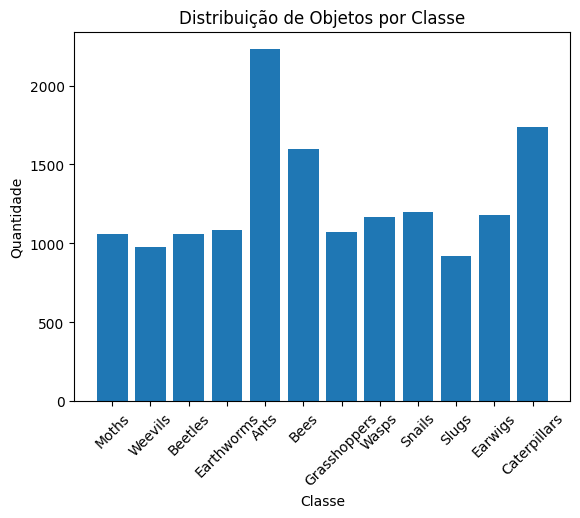

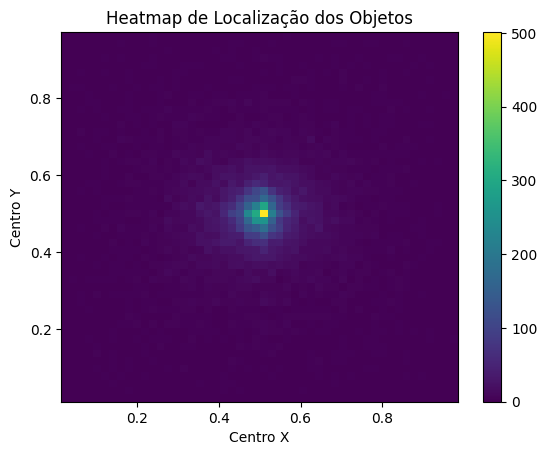

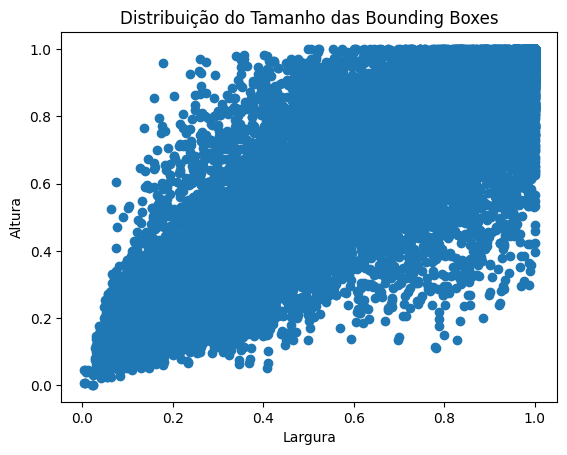

In [59]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import yaml

# ===============================
# Carregar nomes das classes
# ===============================

with open(os.path.join(dataset_path, "data.yaml"), "r") as f:
    yaml_data = yaml.safe_load(f)

class_names = yaml_data["names"]

# ===============================
# Ler labels
# ===============================

labels_path = os.path.join(dataset_path, "train/labels")

classes = []
widths = []
heights = []
centers_x = []
centers_y = []

for file in os.listdir(labels_path):
    
    if file.endswith(".txt"):
        
        with open(os.path.join(labels_path, file)) as f:
            
            for line in f.readlines():
                
                c, x, y, w, h = map(float, line.split())
                
                classes.append(int(c))
                centers_x.append(x)
                centers_y.append(y)
                widths.append(w)
                heights.append(h)

# ===============================
# Distribuição de Classes
# ===============================

class_counts = Counter(classes)

print("\n===== OBJETOS POR CLASSE =====\n")

for c, q in class_counts.items():
    print(f"{class_names[c]}: {q} objetos")

# ===============================
# Estatísticas
# ===============================

print("\n===== ESTATÍSTICAS =====\n")

print("Total de objetos:", len(classes))
print("Total de classes:", len(class_counts))
print("Bounding box média (largura):", round(np.mean(widths),4))
print("Bounding box média (altura):", round(np.mean(heights),4))

# ===============================
# Gráfico distribuição classes
# ===============================

plt.figure()

labels = [class_names[i] for i in class_counts.keys()]
values = class_counts.values()

plt.bar(labels, values)

plt.title("Distribuição de Objetos por Classe")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.xticks(rotation=45)

plt.show()

# ===============================
# Heatmap das bounding boxes
# ===============================

plt.figure()

plt.hist2d(centers_x, centers_y, bins=50)

plt.title("Heatmap de Localização dos Objetos")
plt.xlabel("Centro X")
plt.ylabel("Centro Y")

plt.colorbar()

plt.show()

# ===============================
# Tamanho dos objetos
# ===============================

plt.figure()

plt.scatter(widths, heights)

plt.title("Distribuição do Tamanho das Bounding Boxes")
plt.xlabel("Largura")
plt.ylabel("Altura")

plt.show()


===== RELATÓRIO DO DATASET =====

Total de imagens: 11502
Total de objetos: 15282
Total de classes: 12
Média de objetos por imagem: 1.33

Tamanho médio das bounding boxes
Largura média: 0.5136
Altura média: 0.5349
Área média: 0.3363

===== OBJETOS POR CLASSE =====
Moths: 1062 objetos
Weevils: 975 objetos
Beetles: 1058 objetos
Earthworms: 1083 objetos
Ants: 2231 objetos
Bees: 1596 objetos
Grasshoppers: 1071 objetos
Wasps: 1167 objetos
Snails: 1199 objetos
Slugs: 918 objetos
Earwigs: 1182 objetos
Caterpillars: 1740 objetos


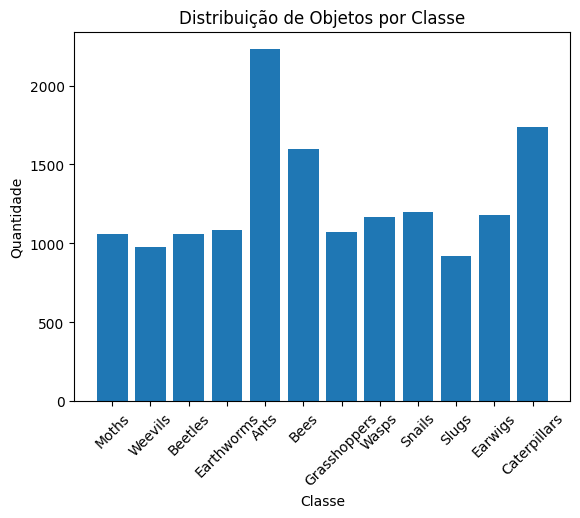

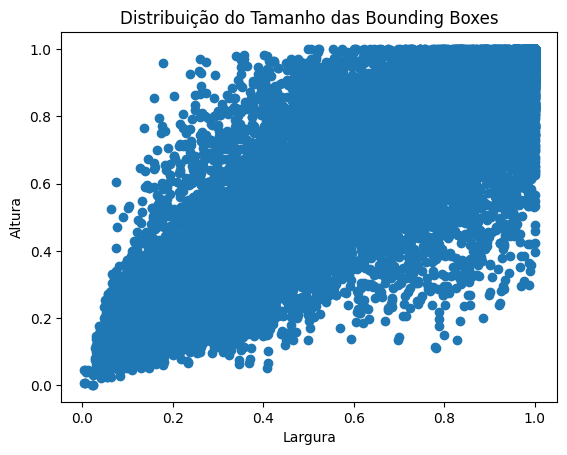

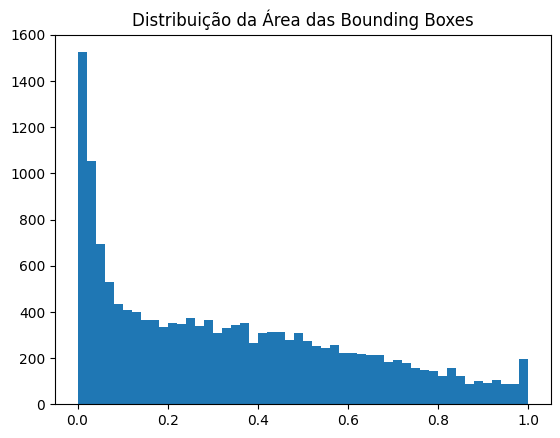


Relatório salvo como: dataset_report.csv


In [60]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import yaml

# ============================
# Carregar nomes das classes
# ============================

with open(os.path.join(dataset_path, "data.yaml"), "r") as f:
    yaml_data = yaml.safe_load(f)

class_names = yaml_data["names"]

# caminhos
labels_path = os.path.join(dataset_path, "train/labels")
images_path = os.path.join(dataset_path, "train/images")

classes = []
widths = []
heights = []
areas = []

# leitura das labels
for file in os.listdir(labels_path):

    if file.endswith(".txt"):

        with open(os.path.join(labels_path, file)) as f:

            for line in f.readlines():

                c, x, y, w, h = map(float, line.split())

                classes.append(int(c))
                widths.append(w)
                heights.append(h)
                areas.append(w*h)

# contagem
class_counts = Counter(classes)

total_images = len(os.listdir(images_path))
total_objects = len(classes)
total_classes = len(class_counts)

objects_per_image = total_objects / total_images

avg_width = np.mean(widths)
avg_height = np.mean(heights)
avg_area = np.mean(areas)

# ============================
# RELATÓRIO
# ============================

print("\n===== RELATÓRIO DO DATASET =====\n")

print("Total de imagens:", total_images)
print("Total de objetos:", total_objects)
print("Total de classes:", total_classes)
print("Média de objetos por imagem:", round(objects_per_image,2))

print("\nTamanho médio das bounding boxes")
print("Largura média:", round(avg_width,4))
print("Altura média:", round(avg_height,4))
print("Área média:", round(avg_area,4))

print("\n===== OBJETOS POR CLASSE =====")

for c,q in class_counts.items():
    print(f"{class_names[c]}: {q} objetos")

# ============================
# GRAFICO CLASSES
# ============================

plt.figure()

labels = [class_names[i] for i in class_counts.keys()]
values = class_counts.values()

plt.bar(labels, values)

plt.title("Distribuição de Objetos por Classe")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.xticks(rotation=45)

plt.show()

# ============================
# TAMANHO DOS OBJETOS
# ============================

plt.figure()

plt.scatter(widths, heights)

plt.title("Distribuição do Tamanho das Bounding Boxes")
plt.xlabel("Largura")
plt.ylabel("Altura")

plt.show()

# ============================
# HISTOGRAMA DE TAMANHOS
# ============================

plt.figure()

plt.hist(areas, bins=50)

plt.title("Distribuição da Área das Bounding Boxes")

plt.show()

# ============================
# TABELA RESUMO
# ============================

report = pd.DataFrame({
    "Metric": [
        "Total Images",
        "Total Objects",
        "Total Classes",
        "Objects per Image",
        "Avg Box Width",
        "Avg Box Height",
        "Avg Box Area"
    ],
    
    "Value": [
        total_images,
        total_objects,
        total_classes,
        round(objects_per_image,2),
        round(avg_width,4),
        round(avg_height,4),
        round(avg_area,4)
    ]
})

report.to_csv("dataset_report.csv", index=False)

print("\nRelatório salvo como: dataset_report.csv")

In [61]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.8 MB/s eta 0:00:0000:010:01


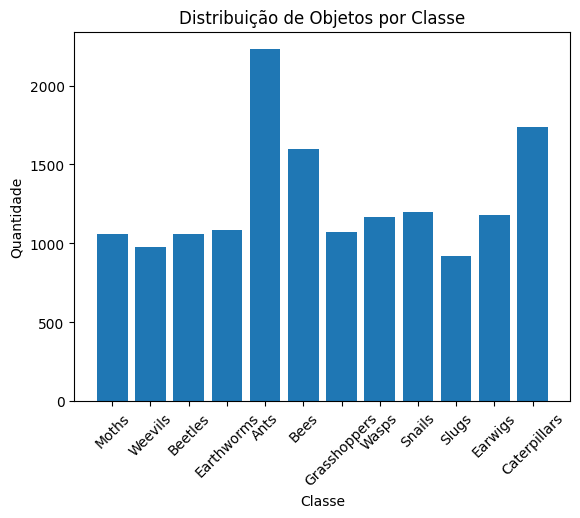

In [66]:
plt.figure()

labels = [class_names[i] for i in class_counts.keys()]
values = class_counts.values()

plt.bar(labels, values)

plt.title("Distribuição de Objetos por Classe")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.xticks(rotation=45)

plt.savefig(f"{output_dir}/distribuicao_classes.png", dpi=300)

plt.show()

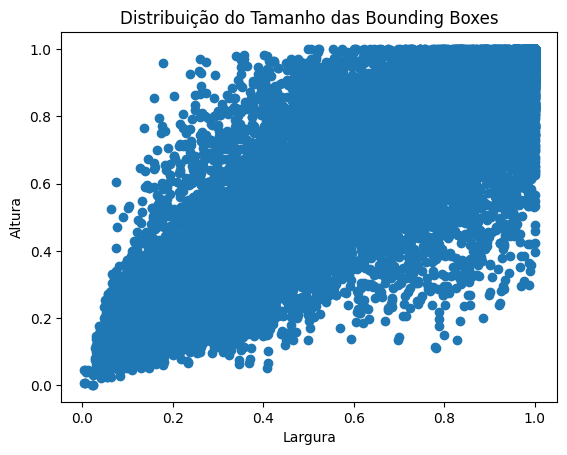

In [67]:
plt.figure()

plt.scatter(widths, heights)

plt.title("Distribuição do Tamanho das Bounding Boxes")
plt.xlabel("Largura")
plt.ylabel("Altura")

plt.savefig(f"{output_dir}/tamanho_objetos.png", dpi=300)

plt.show()

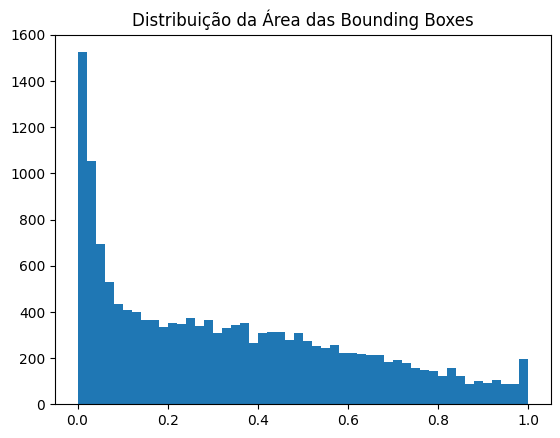

In [68]:
plt.figure()

plt.hist(areas, bins=50)

plt.title("Distribuição da Área das Bounding Boxes")

plt.savefig(f"{output_dir}/histograma_area.png", dpi=300)

plt.show()

In [69]:
print(os.listdir("relatorio_dataset"))

['tamanho_objetos.png', 'distribuicao_classes.png', 'histograma_area.png']


In [72]:
!zip -r relatorio_dataset.zip relatorio_dataset

updating: relatorio_dataset/ (stored 0%)
updating: relatorio_dataset/tamanho_objetos.png (deflated 14%)
updating: relatorio_dataset/distribuicao_classes.png (deflated 19%)
updating: relatorio_dataset/histograma_area.png (deflated 28%)


In [74]:
import os
os.listdir()

['yolov8n.pt',
 '.virtual_documents',
 'yolo11m.pt',
 'resultados_extraidos',
 'dataset_report.csv',
 'runs',
 'agropest_fixed.yaml',
 'relatorio_dataset',
 'sample_inference',
 'yolo26n.pt',
 'relatorio_dataset.zip',
 'Resultados_Completos_PI.zip',
 'comparacao_yolov8n_vs_yolo11m.csv']

In [75]:
from IPython.display import FileLink

FileLink("relatorio_dataset.zip")

/kaggle/working/relatorio_dataset.zip

In [76]:
import pandas as pd

yolo11_path = "resultados_extraidos/kaggle/working/runs/detect/Projeto_Integrador_Rafa/yolo_treinamento/results.csv"
yolov8_path = "resultados_extraidos/kaggle/working/runs/detect/Projeto_Integrador/yolo_treinamento/results.csv"

yolo11 = pd.read_csv(yolo11_path)
yolov8 = pd.read_csv(yolov8_path)

In [77]:
import os

output_dir_training = "relatorio_treinamento"
os.makedirs(output_dir_training, exist_ok=True)

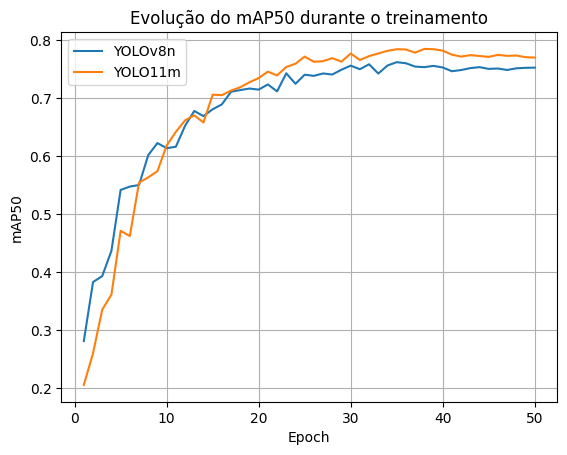

In [78]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(yolov8["epoch"], yolov8["metrics/mAP50(B)"], label="YOLOv8n")
plt.plot(yolo11["epoch"], yolo11["metrics/mAP50(B)"], label="YOLO11m")

plt.title("Evolução do mAP50 durante o treinamento")
plt.xlabel("Epoch")
plt.ylabel("mAP50")

plt.legend()
plt.grid()

plt.savefig(f"{output_dir_training}/evolucao_map50.png", dpi=300)

plt.show()

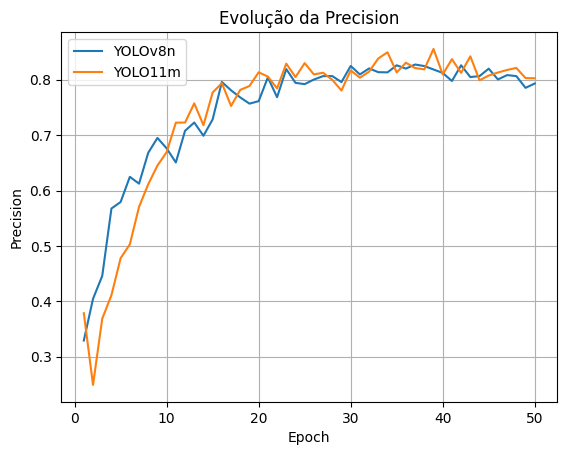

In [79]:
plt.figure()

plt.plot(yolov8["epoch"], yolov8["metrics/precision(B)"], label="YOLOv8n")
plt.plot(yolo11["epoch"], yolo11["metrics/precision(B)"], label="YOLO11m")

plt.title("Evolução da Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")

plt.legend()
plt.grid()

plt.savefig(f"{output_dir_training}/evolucao_precision.png", dpi=300)

plt.show()

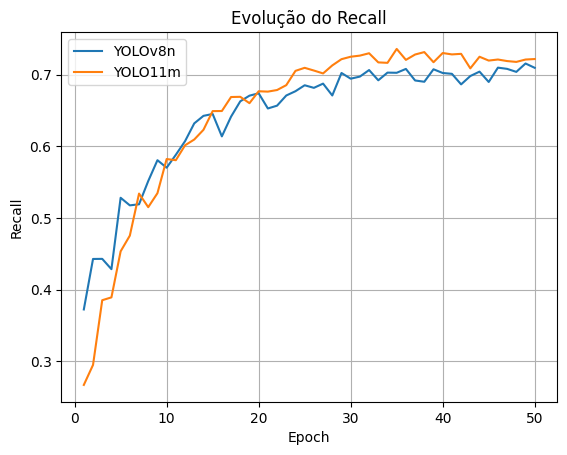

In [80]:
plt.figure()

plt.plot(yolov8["epoch"], yolov8["metrics/recall(B)"], label="YOLOv8n")
plt.plot(yolo11["epoch"], yolo11["metrics/recall(B)"], label="YOLO11m")

plt.title("Evolução do Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")

plt.legend()
plt.grid()

plt.savefig(f"{output_dir_training}/evolucao_recall.png", dpi=300)

plt.show()

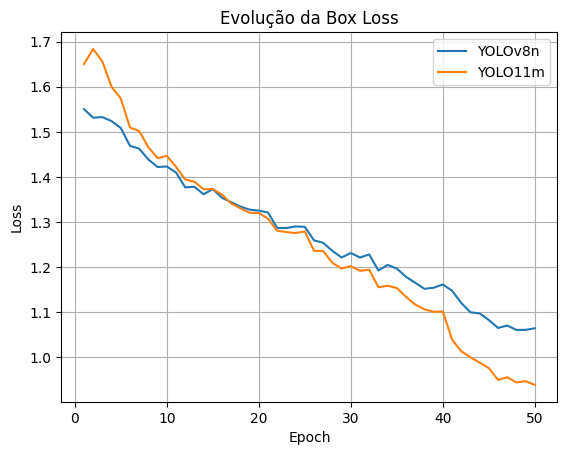

In [81]:
plt.figure()

plt.plot(yolov8["epoch"], yolov8["train/box_loss"], label="YOLOv8n")
plt.plot(yolo11["epoch"], yolo11["train/box_loss"], label="YOLO11m")

plt.title("Evolução da Box Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.savefig(f"{output_dir_training}/evolucao_loss.png", dpi=300)

plt.show()

In [82]:
!zip -r relatorio_treinamento.zip relatorio_treinamento

  adding: relatorio_treinamento/ (stored 0%)
  adding: relatorio_treinamento/evolucao_precision.png (deflated 11%)
  adding: relatorio_treinamento/evolucao_map50.png (deflated 13%)
  adding: relatorio_treinamento/evolucao_recall.png (deflated 12%)
  adding: relatorio_treinamento/evolucao_loss.png (deflated 13%)


In [83]:
from IPython.display import FileLink
FileLink("relatorio_treinamento.zip")

/kaggle/working/relatorio_treinamento.zip